## Muat data 

In [112]:
import pandas as pd

df=pd.read_csv('data/healthcare-dataset-stroke-data.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### EDA Awal

1. Melihat struktur data dan tipe data

In [113]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


(5110, 12)

2. melihat statistik deskriptifnya

In [114]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


3. melihat distribusi data variabel respon

In [115]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

### Data Cleaning

1. cek dan tangani missing value (jika ada)

In [116]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [117]:
df['bmi']=df['bmi'].fillna(df['bmi'].median())
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

2. cek dan tangani nilai duplikat (jika ada)

In [118]:
df.duplicated().sum()

np.int64(0)

3. cek tipe data

In [119]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

4. cek outlier dan tangani (jika ada)

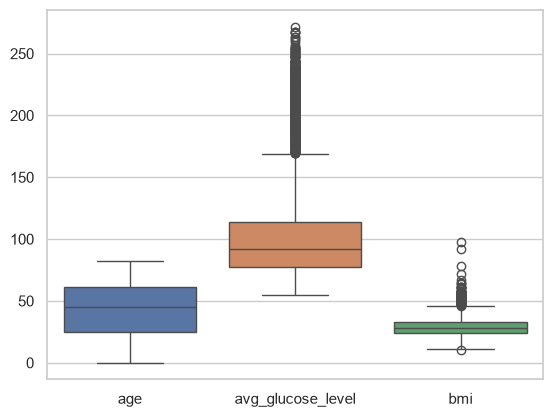

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df[['age','avg_glucose_level','bmi']])
plt.show()



In [121]:
def handle_outliers_iqr(df, columns):
    df_clean=df.copy()
    for col in columns:
        Q1=df_clean[col].quantile(0.25)
        Q3=df_clean[col].quantile(0.75)
        IQR=Q3-Q1

        # batas bawah dan atas
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR

        # ubah nilai
        df_clean[col]=df_clean[col].clip(lower=lower_bound, upper=upper_bound)

    return df_clean

num_cols=['avg_glucose_level','bmi']
df=handle_outliers_iqr(df,num_cols)



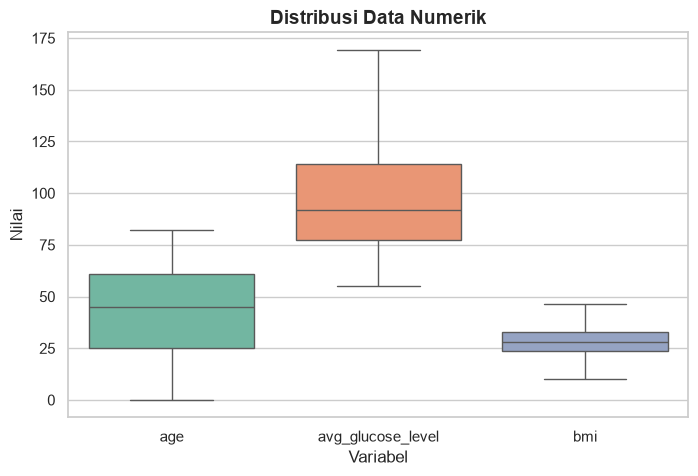

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur style latar belakang
sns.set_theme(style="whitegrid")

# Buat boxplot dengan warna berbeda per kolom
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['age', 'avg_glucose_level', 'bmi']], palette="Set2")

plt.title("Distribusi Data Numerik", fontsize=14, fontweight="bold")
plt.xlabel("Variabel", fontsize=12)
plt.ylabel("Nilai", fontsize=12)
plt.show()

5. cek kategori tidak konsisten

In [123]:
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(col, ':', df[col].unique())

gender : <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
ever_married : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
work_type : <StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
Residence_type : <StringArray>
['Urban', 'Rural']
Length: 2, dtype: str
smoking_status : <StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str


### Data Reduction

cek korelasi

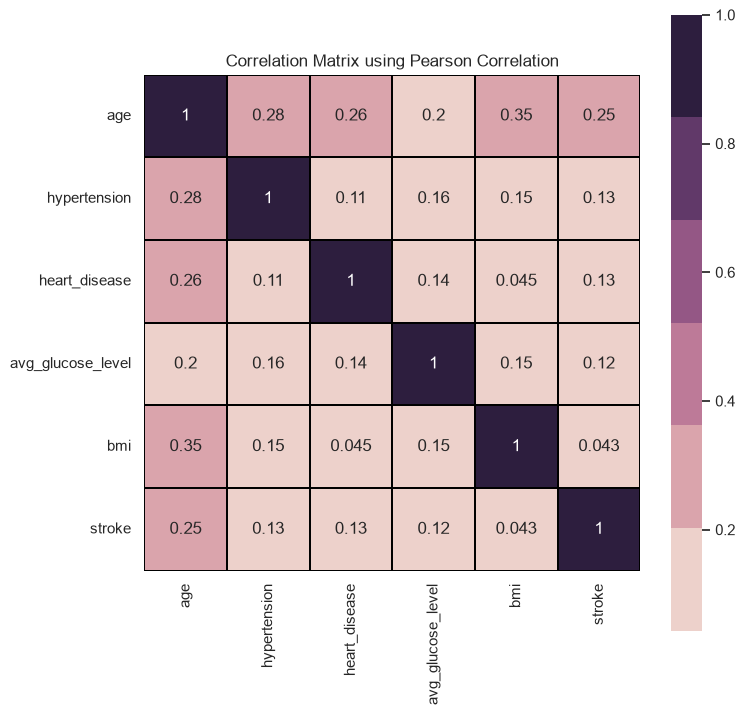

In [124]:

import matplotlib.pyplot as plt
import seaborn as sns

df=df.drop(columns=['id'],errors='ignore')
f, ax=plt.subplots(figsize=(8,8))
plt.title('Correlation Matrix using Pearson Correlation')
sns.heatmap(df.corr(numeric_only=True),linewidths=0.25,vmax=1.0,square=True, linecolor='black',annot=True,cmap=sns.cubehelix_palette())
plt.show()



kerana tidak ada korelasi yang tinggi maka tidak ada feature yang dieliminasi

split data

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Kolom numerik
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

# Kolom kategorikal
categorical_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

# X dan y
X = df.drop(columns=['stroke'])
y = df['stroke']



In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=0)


Data Transform(Buat preprocessing)

Data numerik

In [132]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_num=scaler.fit_transform(X_train[numeric_cols])
X_test_num=scaler.transform(X_test[numeric_cols])

Data Ketegorik

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(handle_unknown='ignore')

X_train_kat=encoder.fit_transform(X_train[categorical_cols])
X_test_kat=encoder.transform(X_test[categorical_cols])



gabungkan data

In [136]:
from scipy.sparse import hstack

X_train_processed=hstack([X_train_num,X_train_kat])
X_test_processed=hstack([X_test_num, X_test_kat])


Membuat Model:

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr=LogisticRegression(solver='liblinear', random_state=0)
model_lr.fit(X_train_processed,y_train)

y_predict=model_lr.predict(X_test_processed)


array([0, 0, 0, ..., 0, 0, 0], shape=(1022,))

Evaluasi Model

In [140]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy=accuracy_score(y_test,y_predict)


print('accurcy :',accuracy)


print(classification_report(y_test, y_predict))

accurcy : 0.9471624266144814
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       968
           1       0.00      0.00      0.00        54

    accuracy                           0.95      1022
   macro avg       0.47      0.50      0.49      1022
weighted avg       0.90      0.95      0.92      1022



c:\Users\MyBook Hype\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MyBook Hype\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MyBook Hype\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

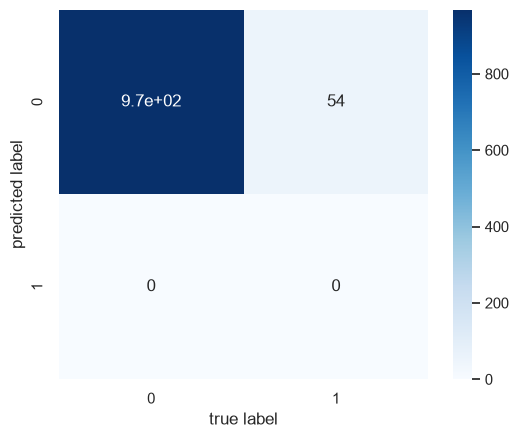

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

#Melakukan evaluasi model dengan confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm.T, square=True, annot=True, cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()

In [143]:
from sklearn.metrics import accuracy_score

y_train_predict = model_lr.predict(X_train_processed)

accuracy_train = accuracy_score(y_train, y_train_predict)

print("Accuracy Train:", accuracy_train)

y_predict = model_lr.predict(X_test_processed)

accuracy_test = accuracy_score(y_test, y_predict)

print("Accuracy Test:", accuracy_test)

Accuracy Train: 0.9522994129158513
Accuracy Test: 0.9471624266144814


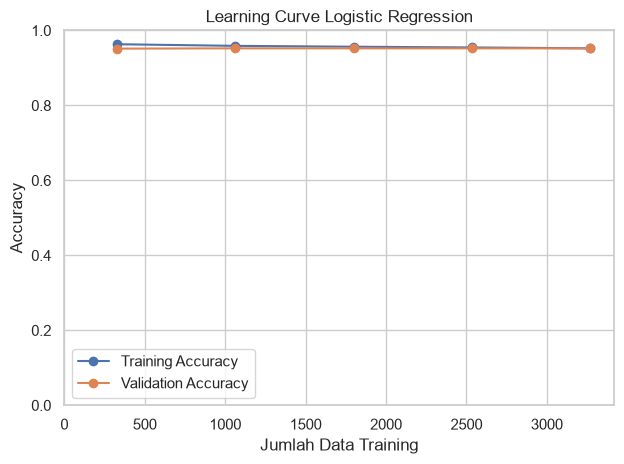

In [152]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    model_lr,
    X_train_processed,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='o', label='Validation Accuracy')

plt.xlabel('Jumlah Data Training')
plt.ylabel('Accuracy')
plt.title('Learning Curve Logistic Regression')

# Mulai sumbu dari 0
plt.xlim(0)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()